In [1]:
import pandas as pd
import glob
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
import numpy as np

/home/aegis/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
regions_path = "/home/aegis/Titan1/NRAD/data/Regions_ver2"
data_regions_path = "/home/aegis/Titan1/NRAD/data/Regions_data"

SCALAR_VARS = ["met_recalc_pt", "met_recalc_phi", "weight_phys"]
VECTOR_VARS = ["AnalysisJetsAuxDyn_pt", "AnalysisJetsAuxDyn_eta", "AnalysisJetsAuxDyn_phi", 
               "AnalysisLargeRJetsAuxDyn_pt", "AnalysisLargeRJetsAuxDyn_eta", "AnalysisLargeRJetsAuxDyn_phi",
               "AnalysisLargeRJetsAuxDyn_Tau1_wta", "AnalysisLargeRJetsAuxDyn_Tau2_wta", "AnalysisLargeRJetsAuxDyn_Tau3_wta", 
               ]

columns_to_load = SCALAR_VARS + VECTOR_VARS


MC_NEW_HLVS = [
    "ht",
    "met_recalc_pt", 
    "mjj", 
    "pt_balance", 
    "dphi_j1_j2", 
    "ljet1_tau21", "ljet1_tau32", 
    "ljet2_tau21", "ljet2_tau32", 
    "min_dphi_jet_met", 
    "weight_phys"
]
DATA_NEW_HLVS = [
    "ht",
    "met_recalc_pt", 
    "mjj", 
    "pt_balance", 
    "dphi_j1_j2", 
    "ljet1_tau21", "ljet1_tau32", 
    "ljet2_tau21", "ljet2_tau32", 
    "min_dphi_jet_met"
]

CRS = ["CR_emu", "CR0L", "CR1ele", "CR1eleb", "CR1mu", "CR1mub", "CR2ele", "CR2mu"]
# "CR_emu", 
MC_SAMPLES = ["Diboson", "Multijet", "Single_top", "ttbar", "Wjets", "Zjets"]

context_var = ['ht', 'met_recalc_pt']
features = ['mjj', 'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32']

In [3]:
def delta_phi(phi1, phi2):
    # The standard "wrap-around" logic
    dphi = (phi1 - phi2 + np.pi) % (2 * np.pi) - np.pi
    return dphi
def prepare_events(events):

    jets = ak.zip({
        "pt": events["AnalysisJetsAuxDyn_pt"],
        "eta": events["AnalysisJetsAuxDyn_eta"],
        "phi": events["AnalysisJetsAuxDyn_phi"],
        "mass": ak.zeros_like(events["AnalysisJetsAuxDyn_pt"])
    }, with_name="Momentum4D")

    ljs = ak.zip({
        "pt": events["AnalysisLargeRJetsAuxDyn_pt"],
        "tau1": events["AnalysisLargeRJetsAuxDyn_Tau1_wta"],
        "tau2": events["AnalysisLargeRJetsAuxDyn_Tau2_wta"],
        "tau3": events["AnalysisLargeRJetsAuxDyn_Tau3_wta"]
    })

    met = ak.zip({
        "pt": events["met_recalc_pt"],
        "phi": events["met_recalc_phi"]
    }, with_name="Momentum2D")


    events["ht"] = ak.sum(events["AnalysisJetsAuxDyn_pt"], axis=1)/1000

    j_lead = jets[:, 0]
    j_sub  = jets[:, 1]

    events["mjj"] = np.sqrt(2 * j_lead.pt * j_sub.pt * (np.cosh(j_lead.eta - j_sub.eta) - np.cos(j_lead.phi - j_sub.phi)))/1000

    met_phi = events["met_recalc_phi"]
    # We need to broadcast MET phi to match the shape of the jet array for subtraction
    # e.g., if Event 1 has 3 jets, we need [met_phi, met_phi, met_phi]
    jet_phi = events["AnalysisJetsAuxDyn_phi"]
    met_phi_broadcasted = ak.broadcast_arrays(met_phi, jet_phi)[0]

    # B. Calculate dPhi between ALL jets and MET
    dphi_jet_met = np.abs(delta_phi(jet_phi, met_phi_broadcasted))

    # --- Save Variable: Min dPhi(Jet, MET) ---
    events["min_dphi_jet_met"] = ak.min(dphi_jet_met, axis=1)

    idx_closest = ak.argmin(dphi_jet_met, axis=1, keepdims=True)
    idx_farthest = ak.argmax(dphi_jet_met, axis=1, keepdims=True)

    # D. Extract pt and phi for these specific jets
    # syntax: array[indices] gives us the specific values
    pt_closest = events["AnalysisJetsAuxDyn_pt"][idx_closest][:, 0]
    phi_closest = events["AnalysisJetsAuxDyn_phi"][idx_closest][:, 0]

    pt_farthest = events["AnalysisJetsAuxDyn_pt"][idx_farthest][:, 0]
    phi_farthest = events["AnalysisJetsAuxDyn_phi"][idx_farthest][:, 0]

    # E. Calculate Vector Sum of the two jets (Numerator)
    # We add their x and y components
    vec_sum_px = (pt_closest * np.cos(phi_closest)) + (pt_farthest * np.cos(phi_farthest))
    vec_sum_py = (pt_closest * np.sin(phi_closest)) + (pt_farthest * np.sin(phi_farthest))
    vec_sum_pt = np.sqrt(vec_sum_px**2 + vec_sum_py**2)

    # F. Calculate Scalar Sum (Denominator)
    scalar_sum_pt = pt_closest + pt_farthest

    # G. Final Calculation
    # events["pt_balance"] = vec_sum_pt / scalar_sum_pt
    denom_safe = scalar_sum_pt > 0
    raw_balance = vec_sum_pt / scalar_sum_pt

    # Use ak.where to replace the bad values with 0
    # Syntax: ak.where(condition, value_if_true, value_if_false)
    events["pt_balance"] = ak.where(denom_safe, raw_balance, 0)

    events["dphi_j1_j2"] = np.abs(delta_phi(phi_closest, phi_farthest))

    # Leading Large-R Jet (Index 0)
    tau1_lead = events["AnalysisLargeRJetsAuxDyn_Tau1_wta"][:, 0]
    tau2_lead = events["AnalysisLargeRJetsAuxDyn_Tau2_wta"][:, 0]
    tau3_lead = events["AnalysisLargeRJetsAuxDyn_Tau3_wta"][:, 0]

    events["ljet1_tau21"] = ak.where(tau1_lead > 0, tau2_lead / tau1_lead, 0)
    events["ljet1_tau32"] = ak.where(tau2_lead > 0, tau3_lead / tau2_lead, 0)

    # Subleading Large-R Jet (Index 1)
    tau1_sub = events["AnalysisLargeRJetsAuxDyn_Tau1_wta"][:, 1]
    tau2_sub = events["AnalysisLargeRJetsAuxDyn_Tau2_wta"][:, 1]
    tau3_sub = events["AnalysisLargeRJetsAuxDyn_Tau3_wta"][:, 1]

    events["ljet2_tau21"] = ak.where(tau1_sub > 0, tau2_sub / tau1_sub, 0)
    events["ljet2_tau32"] = ak.where(tau2_sub > 0, tau3_sub / tau2_sub, 0)

    print("Calculation complete. New variables added to 'events'.")

    return events

def plot_stacked_distributions(
    dfs_dict,
    context_vars,
    feature_vars,
    data_df=None,   # ✅ NEW
    bins=20,
    figsize=(18, 8),
    weight=False
):
    all_vars = context_vars + feature_vars
    n_cols = max(len(context_vars), len(feature_vars))
    n_rows = 2

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, constrained_layout=True)

    if n_cols == 1:
        axes = np.array(axes).reshape(2, 1)

    for col, var in enumerate(all_vars):
        row = 0 if col < len(context_vars) else 1
        col_idx = col if row == 0 else col - len(context_vars)

        ax = axes[row, col_idx]

        data_list = []
        weights_list = []
        labels = []

        # -------- MC STACK --------
        for label, df in dfs_dict.items():
            if var not in df.columns:
                continue

            values = df[var].dropna()

            if weight:
                weights = df.loc[values.index, "weight_phys"]/1000
            else:
                weights = np.ones_like(values)

            data_list.append(values)
            weights_list.append(weights)
            labels.append(label)

        # Compute common bins
        all_values = np.concatenate([v.values for v in data_list if len(v) > 0])
        if len(all_values) == 0:
            continue

        bin_edges = np.histogram_bin_edges(all_values, bins=bins)

        # Plot stacked MC
        ax.hist(
            data_list,
            bins=bin_edges,
            weights=weights_list,
            stacked=True,
            label=labels
        )

        # -------- DATA OVERLAY --------
        if data_df is not None and var in data_df.columns:
            data_values = data_df[var].dropna()

            counts, _ = np.histogram(data_values, bins=bin_edges)
            bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

            # Poisson errors
            errors = np.sqrt(counts)

            ax.errorbar(
                bin_centers,
                counts,
                yerr=errors,
                fmt='o',
                color='black',
                label='Data'
            )

        # -------- STYLING --------
        if var in ["ht", "met_recalc_pt"]:
            ax.set_yscale("log")

        ax.set_title(var)
        ax.set_ylabel("Events")

        if row == 1:
            ax.set_xlabel(var)

    # Remove empty subplots
    for i in range(len(context_vars), n_cols):
        axes[0, i].axis("off")
    for i in range(len(feature_vars), n_cols):
        axes[1, i].axis("off")

    axes[0, 0].legend()

    plt.show()
    
def load_process_df(files, is_data=False):
    events = ak.from_parquet(files, columns=columns_to_load)
    events = prepare_events(events)

    cols = DATA_NEW_HLVS if is_data else MC_NEW_HLVS
    return ak.to_dataframe(events[cols])

def plot_cr(cr_name):
    plot_stacked_distributions(
        all_results[cr_name]["mc"],
        context_var,
        features,
        data_df=all_results[cr_name]["data"],
        weight=False
    )


In [4]:
all_results = {}

for cr in CRS:
    print(f"Processing {cr}...")

    mc_dfs = {}

    for sample in MC_SAMPLES:
        files = glob.glob(f"{regions_path}/{cr}/{sample}*.parquet")
        mc_dfs[sample] = load_process_df(files)

    data_files = glob.glob(f"{data_regions_path}/{cr}/*.parquet")

    data_df = load_process_df(data_files, is_data=True)

    all_results[cr] = {
        "mc": mc_dfs,
        "data": data_df
    }

Processing CR_emu...


/home/aegis/.local/lib/python3.10/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


Calculation complete. New variables added to 'events'.


/home/aegis/.local/lib/python3.10/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


Calculation complete. New variables added to 'events'.


...

Calculation complete. New variables added to 'events'.


/home/aegis/.local/lib/python3.10/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


Calculation complete. New variables added to 'events'.
Processing CR2ele...
Calculation complete. New variables added to 'events'.
Calculation complete. New variables added to 'events'.


/home/aegis/.local/lib/python3.10/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


ValueError: empty urlpath sequence

In [63]:
files_diboson_CR_emu = glob.glob(f"{regions_path}/CR_emu/Diboson*.parquet")
files_Multijet_CR_emu = glob.glob(f"{regions_path}/CR_emu/Multijet*.parquet")
files_Single_top_CR_emu = glob.glob(f"{regions_path}/CR_emu/Single_top*.parquet")
files_ttbar_CR_emu = glob.glob(f"{regions_path}/CR_emu/ttbar*.parquet")
files_Wjets_CR_emu = glob.glob(f"{regions_path}/CR_emu/Wjets*.parquet")
files_Zjets_CR_emu = glob.glob(f"{regions_path}/CR_emu/Zjets*.parquet")
files_data_CR_emu = glob.glob(f"{data_regions_path}/CR_emu/*.parquet")

diboson_CR_emu_events = ak.from_parquet(files_diboson_CR_emu, columns=columns_to_load)
Multijet_CR_emu_events = ak.from_parquet(files_Multijet_CR_emu, columns=columns_to_load)
Single_top_CR_emu_events = ak.from_parquet(files_Single_top_CR_emu, columns=columns_to_load)
ttbar_CR_emu_events = ak.from_parquet(files_ttbar_CR_emu, columns=columns_to_load)
Wjets_CR_emu_events = ak.from_parquet(files_Wjets_CR_emu, columns=columns_to_load)
Zjets_CR_emu_events = ak.from_parquet(files_Zjets_CR_emu, columns=columns_to_load)  
data_CR_emu_events = ak.from_parquet(files_data_CR_emu, columns=columns_to_load)



In [64]:
kin_diboson_CR_emu_events = prepare_events(diboson_CR_emu_events)
kin_Multijet_CR_emu_events = prepare_events(Multijet_CR_emu_events)
kin_Single_top_CR_emu_events = prepare_events(Single_top_CR_emu_events)
kin_ttbar_CR_emu_events = prepare_events(ttbar_CR_emu_events)
kin_Wjets_CR_emu_events = prepare_events(Wjets_CR_emu_events)
kin_Zjets_CR_emu_events = prepare_events(Zjets_CR_emu_events)
kin_data_CR_emu_events = prepare_events(data_CR_emu_events)

/home/aegis/.local/lib/python3.10/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


Calculation complete. New variables added to 'events'.
Calculation complete. New variables added to 'events'.
Calculation complete. New variables added to 'events'.
Calculation complete. New variables added to 'events'.
Calculation complete. New variables added to 'events'.
Calculation complete. New variables added to 'events'.
Calculation complete. New variables added to 'events'.


In [72]:
diboson_CR_emu_df = ak.to_dataframe(kin_diboson_CR_emu_events[MC_NEW_HLVS])
Multijet_CR_emu_df = ak.to_dataframe(kin_Multijet_CR_emu_events[MC_NEW_HLVS])
Single_top_CR_emu_df = ak.to_dataframe(kin_Single_top_CR_emu_events[MC_NEW_HLVS])
ttbar_CR_emu_df = ak.to_dataframe(kin_ttbar_CR_emu_events[MC_NEW_HLVS])
Wjets_CR_emu_df = ak.to_dataframe(kin_Wjets_CR_emu_events[MC_NEW_HLVS])
Zjets_CR_emu_df = ak.to_dataframe(kin_Zjets_CR_emu_events[MC_NEW_HLVS])
data_CR_emu_df = ak.to_dataframe(kin_data_CR_emu_events[DATA_NEW_HLVS])

In [74]:
context_var = ['ht', 'met_recalc_pt']
features = ['mjj', 'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32']

In [79]:
import matplotlib.pyplot as plt
import numpy as np

def plot_stacked_distributions(
    dfs_dict,
    context_vars,
    feature_vars,
    data_df=None,   # ✅ NEW
    bins=20,
    figsize=(18, 8),
    weight=False
):
    all_vars = context_vars + feature_vars
    n_cols = max(len(context_vars), len(feature_vars))
    n_rows = 2

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, constrained_layout=True)

    if n_cols == 1:
        axes = np.array(axes).reshape(2, 1)

    for col, var in enumerate(all_vars):
        row = 0 if col < len(context_vars) else 1
        col_idx = col if row == 0 else col - len(context_vars)

        ax = axes[row, col_idx]

        data_list = []
        weights_list = []
        labels = []

        # -------- MC STACK --------
        for label, df in dfs_dict.items():
            if var not in df.columns:
                continue

            values = df[var].dropna()

            if weight:
                weights = df.loc[values.index, "weight_phys"]/1000
            else:
                weights = np.ones_like(values)

            data_list.append(values)
            weights_list.append(weights)
            labels.append(label)

        # Compute common bins
        all_values = np.concatenate([v.values for v in data_list if len(v) > 0])
        if len(all_values) == 0:
            continue

        bin_edges = np.histogram_bin_edges(all_values, bins=bins)

        # Plot stacked MC
        ax.hist(
            data_list,
            bins=bin_edges,
            weights=weights_list,
            stacked=True,
            label=labels
        )

        # -------- DATA OVERLAY --------
        if data_df is not None and var in data_df.columns:
            data_values = data_df[var].dropna()

            counts, _ = np.histogram(data_values, bins=bin_edges)
            bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

            # Poisson errors
            errors = np.sqrt(counts)

            ax.errorbar(
                bin_centers,
                counts,
                yerr=errors,
                fmt='o',
                color='black',
                label='Data'
            )

        # -------- STYLING --------
        if var in ["ht", "met_recalc_pt"]:
            ax.set_yscale("log")

        ax.set_title(var)
        ax.set_ylabel("Events")

        if row == 1:
            ax.set_xlabel(var)

    # Remove empty subplots
    for i in range(len(context_vars), n_cols):
        axes[0, i].axis("off")
    for i in range(len(feature_vars), n_cols):
        axes[1, i].axis("off")

    axes[0, 0].legend()

    plt.show()

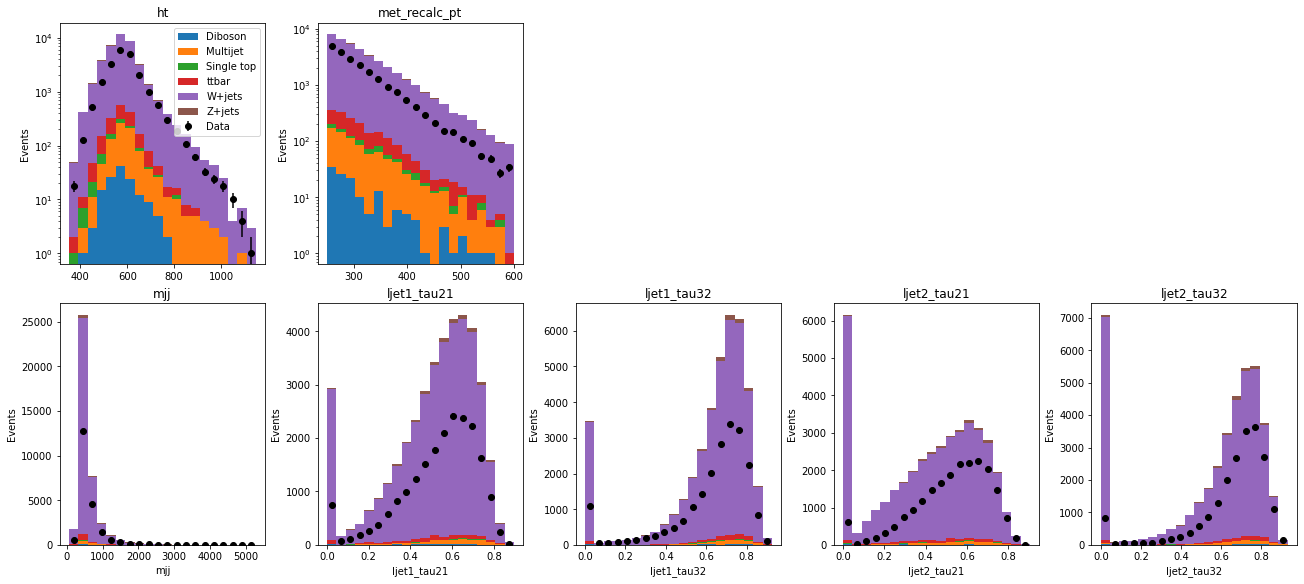

In [ ]:
dfs_CR_emu = {
    "Diboson": diboson_CR_emu_df,
    "Multijet": Multijet_CR_emu_df,
    "Single top": Single_top_CR_emu_df,
    "ttbar": ttbar_CR_emu_df,
    "W+jets": Wjets_CR_emu_df,
    "Z+jets": Zjets_CR_emu_df,
}

context_var = ['ht', 'met_recalc_pt']
features = ['mjj', 'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32']

plot_stacked_distributions(
    dfs_CR_emu,
    context_var,
    features,
    data_df=data_CR_emu_df,  # ✅ pass data here
    weight=False              # usually True for MC
)